# Reproduce 3-Channel Results

This notebook loads the best `val_IoU` checkpoints for the three 3-channel models, recreates the compact training curves, recomputes validation/test metrics, and builds qualitative grids for high-IoU examples.

### Sanay:
I uploaded the relevant models (best runs according to WandB, if you have a local version feel free to swap it out) to our drive folder. They should live in `notebooks/outputs/reproduce_results/` for this notebook to run properly. I'll probably only add a portion of my ablation study, with link to the full notebook if they're interested.

In [7]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/Deep Learning Project/DLE-Flair-Segmentation

!pip install -r requirements.txt

Mounted at /content/drive
/content/drive/MyDrive/Deep Learning Project/DLE-Flair-Segmentation
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 11.3 MB/s eta 0:00:00


In [1]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "src").exists() else NOTEBOOK_DIR.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

os.chdir(REPO_ROOT)
try:
    from dotenv import load_dotenv
    load_dotenv(REPO_ROOT / ".env", override=False)
except ImportError:
    pass

from src.data import build_dataloaders
from src.evaluate import evaluate_test_metrics, load_checkpoint_model
from src.train import sync_class_config
from src.utils import get_device, load_config
from src.visualize import overlay_mask

DEVICE = get_device()
OUT_DIR = REPO_ROOT / "notebooks" / "outputs" / "reproduce_results"
FIG_DIR = OUT_DIR / "figures"
TABLE_DIR = OUT_DIR / "tables"
HISTORY_DIR = OUT_DIR / "history"
for path in (FIG_DIR, TABLE_DIR, HISTORY_DIR):
    path.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print(f"repo: {REPO_ROOT}")
print(f"device: {DEVICE}")

repo: /home/henry/Documents/Coursework/DLE_24788/final_project/DLE-Flair-Segmentation
device: cuda


## 3-Channel Runs

In [2]:
RUNS_3CH = {
    "resnet34_unet_3ch": {
        "label": "ResNet34 U-Net",
        "config": "configs/resnet34_unet_3ch.yaml",
        "checkpoints": ["notebooks/outputs/reproduce_results/models/resnet34_unet_3ch_val_IoU/best.pt",],
    },
    "convnext_tiny_3ch": {
        "label": "ConvNeXt-Tiny",
        "config": "configs/convnext_tiny_3ch.yaml",
        "checkpoints": ["notebooks/outputs/reproduce_results/models/convnext_tiny_3ch_val_IoU/best.pt"],
    },
    "dinov3_convnext_tiny_3ch": {
        "label": "DINOv3 ConvNeXt-Tiny",
        "config": "configs/dinov3_convnext_tiny_3ch.yaml",
        "checkpoints": ["notebooks/outputs/reproduce_results/models/dinov3_convnext_tiny_3ch_val_IoU/best.pt"],
    },
}

RUNS_5CH = {
    "resnet34_unet_5ch": {
        "label": "ResNet34 U-Net (5ch)",
        "config": "configs/resnet34_unet_5ch.yaml",
        "checkpoints": ["notebooks/outputs/reproduce_results/models/resnet34_unet_5ch_val_IoU/best.pt"],
    },
    "convnext_tiny_5ch": {
        "label": "ConvNeXt-Tiny (5ch)",
        "config": "configs/convnext_tiny_5ch.yaml",
        "checkpoints": ["notebooks/outputs/reproduce_results/models/convnext_tiny_5ch_val_IoU/best.pt"],
    },
    "dinov3_convnext_tiny_5ch": {
        "label": "DINOv3 ConvNeXt-Tiny (5ch)",
        "config": "configs/dinov3_convnext_tiny_5ch.yaml",
        "checkpoints": ["notebooks/outputs/reproduce_results/models/dinov3_convnext_tiny_5ch_val_IoU/best.pt"],
    },
}

RUNS_ALL = {**RUNS_3CH, **RUNS_5CH}


def resolve_checkpoint(paths: list[str]) -> Path:
    for path in paths:
        candidate = REPO_ROOT / path
        if candidate.exists():
            return candidate
    raise FileNotFoundError("No checkpoint found. Tried:\n" + "\n".join(paths))


def load_run_config(config_path: str) -> dict[str, Any]:
    config = load_config(REPO_ROOT / config_path)
    return sync_class_config(config)


for run_key, run in RUNS_3CH.items():
    run["checkpoint_path"] = resolve_checkpoint(run["checkpoints"])
    run["config_obj"] = load_run_config(run["config"])
    config = run["config_obj"]
    assert config["checkpoint"]["monitor"] == "val_IoU"
    assert config["checkpoint"]["mode"] == "max"
    assert config["model"]["in_channels"] == 3
    assert config["data"]["channels"] == [1, 2, 3]
    print(f"{run_key}: {run['checkpoint_path'].relative_to(REPO_ROOT)}")

resnet34_unet_3ch: notebooks/outputs/reproduce_results/models/resnet34_unet_3ch_val_IoU/best.pt
convnext_tiny_3ch: notebooks/outputs/reproduce_results/models/convnext_tiny_3ch_val_IoU/best.pt
dinov3_convnext_tiny_3ch: notebooks/outputs/reproduce_results/models/dinov3_convnext_tiny_3ch_val_IoU/best.pt


## Training Histories

The loss/IoU plots read from CSV histories under `notebooks/outputs/reproduce_results/history/`. If a CSV is missing, or if `REFRESH_WANDB_HISTORIES = True`, this cell fetches the history from W&B and rewrites the CSV.


In [3]:
HISTORY_COLUMNS = ["epoch", "train_loss", "val_loss", "val_IoU"]
REFRESH_WANDB_HISTORIES = False


def history_csv_path(run_key: str) -> Path:
    return HISTORY_DIR / f"{run_key}_history.csv"


def normalize_history(history: pd.DataFrame) -> pd.DataFrame:
    history = history.copy()
    if "epoch" not in history.columns:
        if "_step" in history.columns:
            history["epoch"] = history["_step"]
        else:
            history["epoch"] = np.arange(1, len(history) + 1)
    missing = [col for col in HISTORY_COLUMNS if col not in history.columns]
    if missing:
        raise ValueError(f"History is missing required columns: {missing}")
    history = history[HISTORY_COLUMNS].dropna(subset=["train_loss", "val_loss", "val_IoU"], how="all")
    history["epoch"] = history["epoch"].astype(int)
    return history.sort_values("epoch").reset_index(drop=True)


def wandb_project_path(config: dict[str, Any]) -> str:
    wandb_config = config.get("wandb", {})
    project = wandb_config.get("project")
    entity = os.environ.get("WANDB_ENTITY") or wandb_config.get("entity")
    if not project:
        raise ValueError("W&B project is missing from the run config.")
    return f"{entity}/{project}" if entity else project


def fetch_wandb_history(run_key: str, run: dict[str, Any]) -> pd.DataFrame:
    try:
        import wandb
    except ImportError as exc:
        raise ImportError("Install wandb to fetch training histories directly from W&B.") from exc

    config = run["config_obj"]
    experiment_name = config["experiment"]["name"]
    wandb_config = config.get("wandb", {})
    path = wandb_project_path(config)

    api = wandb.Api()
    candidates = list(api.runs(path, filters={"display_name": experiment_name}))
    if not candidates:
        group = wandb_config.get("group")
        group_runs = api.runs(path, filters={"group": group}) if group else api.runs(path)
        candidates = [candidate for candidate in group_runs if candidate.name == experiment_name]
    if not candidates:
        raise LookupError(f"No W&B run found for {experiment_name!r} in {path!r}.")

    selected = sorted(candidates, key=lambda item: item.created_at, reverse=True)[0]
    history = normalize_history(selected.history(keys=HISTORY_COLUMNS, pandas=True))
    output_path = history_csv_path(run_key)
    history.to_csv(output_path, index=False)
    print(f"{run_key}: fetched W&B history from {path}/{selected.id} -> {output_path.relative_to(REPO_ROOT)}")
    return history


def load_or_fetch_history(run_key: str, run: dict[str, Any]) -> pd.DataFrame:
    csv_path = history_csv_path(run_key)
    if csv_path.exists() and not REFRESH_WANDB_HISTORIES:
        print(f"{run_key}: loaded history from {csv_path.relative_to(REPO_ROOT)}")
        return normalize_history(pd.read_csv(csv_path))
    return fetch_wandb_history(run_key, run)


histories = {
    run_key: load_or_fetch_history(run_key, run)
    for run_key, run in RUNS_3CH.items()
}

display(pd.concat({key: value.tail(1) for key, value in histories.items()}, names=["run", "row"]))


resnet34_unet_3ch: loaded history from notebooks/outputs/reproduce_results/history/resnet34_unet_3ch_history.csv
convnext_tiny_3ch: loaded history from notebooks/outputs/reproduce_results/history/convnext_tiny_3ch_history.csv
dinov3_convnext_tiny_3ch: loaded history from notebooks/outputs/reproduce_results/history/dinov3_convnext_tiny_3ch_history.csv


,,epoch,train_loss,val_loss,val_IoU
run,row,,,,
resnet34_unet_3ch,54,55,1.018632,0.762757,0.602271
convnext_tiny_3ch,50,51,0.659735,0.697076,0.635827
dinov3_convnext_tiny_3ch,83,84,0.636522,0.713166,0.651978


## Training Curves

The first figure shows only train/validation loss for the 3-channel models. The second shows validation IoU.

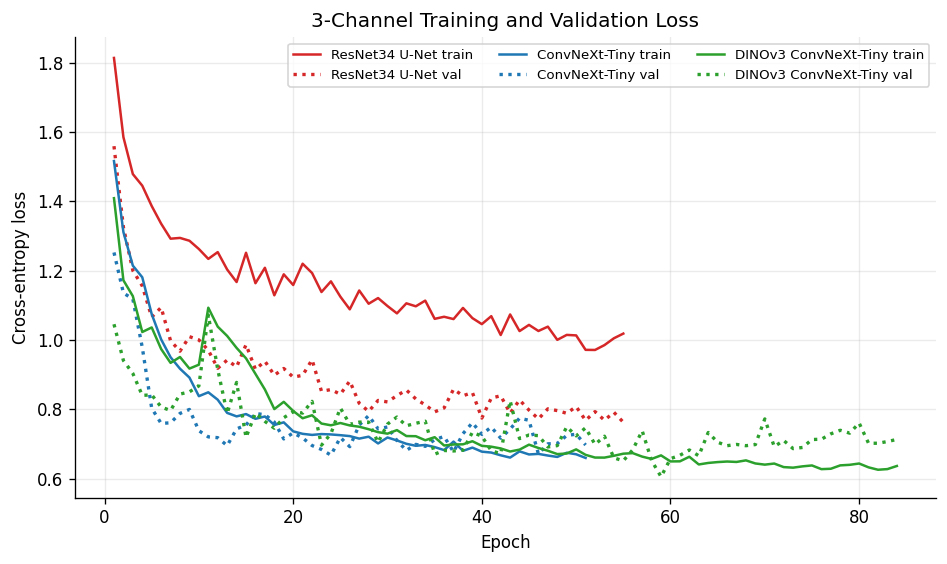

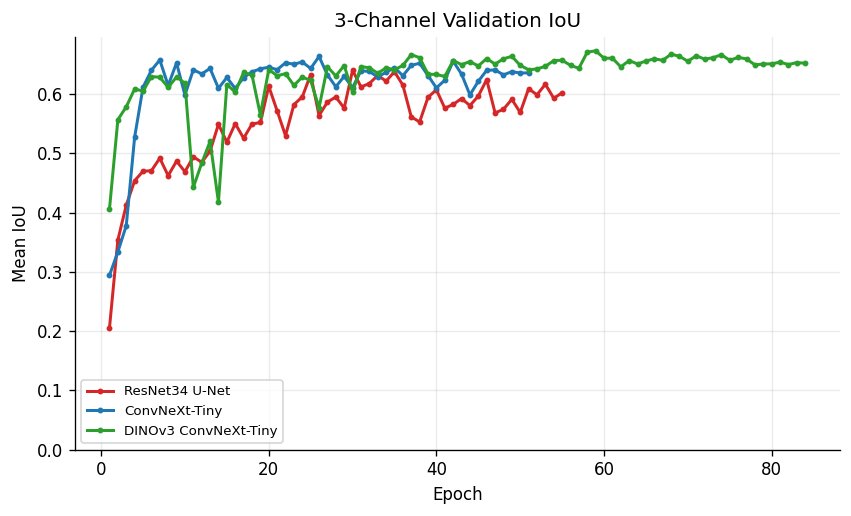

In [4]:
MODEL_COLORS = {
    "resnet34_unet_3ch": "#d62728",  # red
    "convnext_tiny_3ch": "#1f77b4",  # blue
    "dinov3_convnext_tiny_3ch": "#2ca02c",  # green
}


def plot_3ch_loss_curves(histories: dict[str, pd.DataFrame]) -> plt.Figure | None:
    if not histories:
        return None
    fig, ax = plt.subplots(figsize=(8, 4.8))
    legend_handles = []
    legend_labels = []
    for run_key, history in histories.items():
        label = RUNS_3CH[run_key]["label"]
        color = MODEL_COLORS[run_key]
        train_line, = ax.plot(history["epoch"], history["train_loss"], color=color, linestyle="-", label=f"{label} train")
        val_line, = ax.plot(history["epoch"], history["val_loss"], color=color, linestyle=":", linewidth=2.0, label=f"{label} val")
        legend_handles.extend([train_line, val_line])
        legend_labels.extend([f"{label} train", f"{label} val"])
    ax.set_title("3-Channel Training and Validation Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Cross-entropy loss")
    ax.grid(alpha=0.25)
    ax.legend(legend_handles, legend_labels, ncol=3, fontsize=8)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "3ch_train_val_loss.png", bbox_inches="tight")
    return fig


def plot_3ch_val_iou(histories: dict[str, pd.DataFrame]) -> plt.Figure | None:
    if not histories:
        return None
    fig, ax = plt.subplots(figsize=(7.2, 4.4))
    for run_key, history in histories.items():
        label = RUNS_3CH[run_key]["label"]
        ax.plot(history["epoch"], history["val_IoU"], color=MODEL_COLORS[run_key], marker="o", markersize=2.5, linewidth=1.8, label=label)
    ax.set_title("3-Channel Validation IoU")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Mean IoU")
    ax.set_ylim(bottom=0)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "3ch_val_iou.png", bbox_inches="tight")
    return fig


loss_fig = plot_3ch_loss_curves(histories)
iou_fig = plot_3ch_val_iou(histories)
plt.show()

## Load Checkpoints And Recompute Metrics

This recomputes validation and test metrics from the best checkpoint for each 3-channel model, then saves summary and per-class tables.

In [5]:
with open(REPO_ROOT / "data" / "processed" / "class_map.json") as file:
    class_map = json.load(file)

CLASS_NAMES = class_map.get("class_names") or class_map.get("target_names") or [str(i) for i in range(class_map["num_classes"])]
NUM_CLASSES = int(class_map["num_classes"])
IGNORE_INDEX = int(class_map.get("ignore_index", 255))

loaded = {}
summary_rows = []
per_class_rows = []

for run_key, run in RUNS_3CH.items():
    print(f"\nLoading {run['label']}")
    config = run["config_obj"]
    model, checkpoint = load_checkpoint_model(run["checkpoint_path"], DEVICE, model_config=config["model"])
    train_loader, val_loader, test_loader = build_dataloaders(config["data"])

    for split_name, loader in [("val", val_loader), ("test", test_loader)]:
        metrics = evaluate_test_metrics(
            model=model,
            dataloader=loader,
            num_classes=NUM_CLASSES,
            device=DEVICE,
            ignore_index=IGNORE_INDEX,
            class_names=CLASS_NAMES,
            desc=f"{run['label']} {split_name}",
        )
        summary_rows.append({
            "run_key": run_key,
            "model": run["label"],
            "split": split_name,
            "checkpoint_epoch": checkpoint.get("epoch"),
            "checkpoint_best_metric": checkpoint.get("best_metric"),
            "pixel_accuracy": metrics["pixel_accuracy"],
            "mIoU": metrics["mIoU"],
            "mean_dice": metrics["mean_dice"],
            "latency_ms_per_patch": metrics["latency_ms_per_patch"],
            "num_pixels": metrics["num_pixels"],
        })
        for row in metrics["class_rows"]:
            per_class_rows.append({
                "run_key": run_key,
                "model": run["label"],
                "split": split_name,
                **row,
            })
        if split_name == "test":
            run["test_metrics"] = metrics

    loaded[run_key] = {
        "model": model,
        "checkpoint": checkpoint,
        "config": config,
        "test_loader": test_loader,
        "val_loader": val_loader,
    }

summary_df = pd.DataFrame(summary_rows)
per_class_df = pd.DataFrame(per_class_rows)
summary_df.to_csv(TABLE_DIR / "3ch_summary_metrics.csv", index=False)
per_class_df.to_csv(TABLE_DIR / "3ch_per_class_metrics.csv", index=False)

display(summary_df.sort_values(["split", "mIoU"], ascending=[True, False]))


Loading ResNet34 U-Net


ResNet34 U-Net test: 100%|██████████| 4/4 [00:00<00:00, 17.30it/s]



Loading ConvNeXt-Tiny


ConvNeXt-Tiny test: 100%|██████████| 4/4 [00:00<00:00, 16.22it/s]



Loading DINOv3 ConvNeXt-Tiny


Loading weights:   0%|          | 0/180 [00:00<?, ?it/s]

DINOv3 ConvNeXt-Tiny test: 100%|██████████| 4/4 [00:00<00:00, 16.09it/s]


,run_key,model,split,checkpoint_epoch,checkpoint_best_metric,pixel_accuracy,mIoU,mean_dice,latency_ms_per_patch,num_pixels
5,dinov3_convnext_tiny_3ch,DINOv3 ConvNeXt-Tiny,test,58,0.668320,0.724596,0.478185,0.604131,5.721955,6553600
1,resnet34_unet_3ch,ResNet34 U-Net,test,30,0.639406,0.728586,0.460463,0.588547,4.677312,6553600
3,convnext_tiny_3ch,ConvNeXt-Tiny,test,26,0.664794,0.692547,0.446567,0.571030,5.648081,6553600
4,dinov3_convnext_tiny_3ch,DINOv3 ConvNeXt-Tiny,val,58,0.668320,0.815562,0.668320,0.791712,5.645567,6553600
2,convnext_tiny_3ch,ConvNeXt-Tiny,val,26,0.664794,0.805760,0.664794,0.789114,19.880322,6553600
0,resnet34_unet_3ch,ResNet34 U-Net,val,30,0.639406,0.792677,0.639406,0.770492,5.820346,6553600


## Pick High-IoU Qualitative Examples

We score each test patch by the mean sample IoU across the three models, then use the top examples for the qualitative grid. Set `MANUAL_SAMPLE_INDICES` to override the automatic choices after visual inspection.

In [6]:
def batch_sample_iou(predictions: torch.Tensor, masks: torch.Tensor, num_classes: int, ignore_index: int = 255) -> list[float]:
    scores = []
    predictions = predictions.detach().cpu()
    masks = masks.detach().cpu()
    for pred, mask in zip(predictions, masks):
        valid = (mask >= 0) & (mask < num_classes)
        if ignore_index is not None:
            valid = valid & (mask != ignore_index)
        class_scores = []
        for class_id in range(num_classes):
            pred_c = (pred == class_id) & valid
            mask_c = (mask == class_id) & valid
            union = (pred_c | mask_c).sum().item()
            if union == 0:
                continue
            intersection = (pred_c & mask_c).sum().item()
            class_scores.append(intersection / union)
        scores.append(float(np.mean(class_scores)) if class_scores else np.nan)
    return scores


@torch.no_grad()
def score_test_samples(loaded: dict[str, dict[str, Any]], max_batches: int | None = None) -> pd.DataFrame:
    first_key = next(iter(loaded))
    loader = loaded[first_key]["test_loader"]
    rows = []
    global_index = 0
    for batch_index, batch in enumerate(tqdm(loader, desc="Scoring test samples")):
        if max_batches is not None and batch_index >= max_batches:
            break
        images = batch["image"].to(DEVICE)
        masks = batch["mask"].long()
        per_model_scores = {}
        for run_key, item in loaded.items():
            model = item["model"]
            logits = model(images)
            predictions = logits.argmax(dim=1)
            per_model_scores[run_key] = batch_sample_iou(predictions, masks, NUM_CLASSES, IGNORE_INDEX)
        batch_size = masks.shape[0]
        for offset in range(batch_size):
            row = {"sample_index": global_index + offset}
            for run_key, scores in per_model_scores.items():
                row[f"{run_key}_iou"] = scores[offset]
            model_values = [row[f"{run_key}_iou"] for run_key in loaded]
            row["mean_model_iou"] = float(np.nanmean(model_values))
            rows.append(row)
        global_index += batch_size
    return pd.DataFrame(rows).sort_values("mean_model_iou", ascending=False).reset_index(drop=True)


sample_scores = score_test_samples(loaded)
sample_scores.to_csv(TABLE_DIR / "3ch_sample_iou_scores.csv", index=False)
display(sample_scores.head(10))

Scoring test samples:   0%|          | 0/4 [00:00<?, ?it/s]

,sample_index,resnet34_unet_3ch_iou,convnext_tiny_3ch_iou,dinov3_convnext_tiny_3ch_iou,mean_model_iou
0,9,0.114290,1.000000,1.000000,0.704763
1,1,0.311823,0.887643,0.890136,0.696534
2,17,0.185441,0.496279,1.000000,0.560573
3,8,0.455221,0.417714,0.503023,0.458653
4,0,0.242967,0.485947,0.485947,0.404953
5,11,0.199144,0.497597,0.497597,0.398113
6,5,0.182882,0.417717,0.584349,0.394983
7,3,0.230685,0.462234,0.483095,0.392005
8,22,0.481600,0.285082,0.406487,0.391057
9,6,0.296275,0.545917,0.325576,0.389256


## Qualitative Grid

Default is `3 x 4`: three high-IoU samples, with columns for ground truth and each model prediction. Use `N_QUALITATIVE = 1` for a `1 x 4` paper figure.

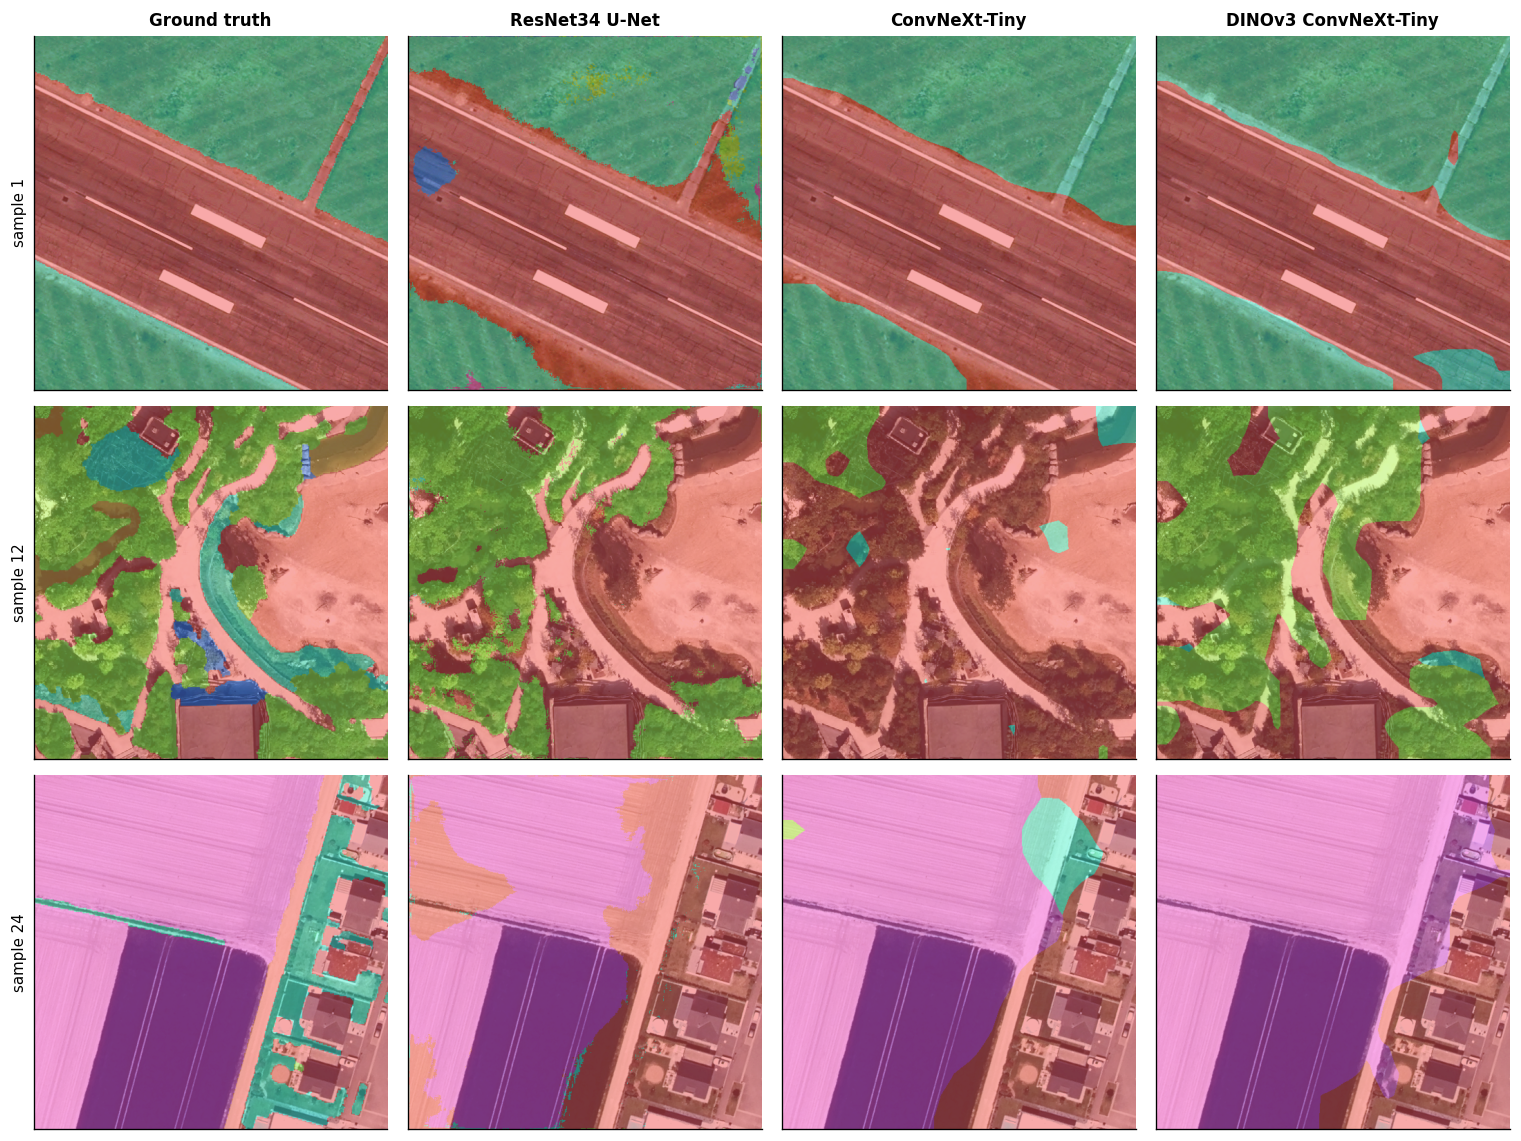

selected sample indices: [1, 12, 24]
saved: /home/henry/Documents/Coursework/DLE_24788/final_project/DLE-Flair-Segmentation/notebooks/outputs/reproduce_results/figures/3ch_best_qualitative_grid.png


In [7]:
MANUAL_SAMPLE_INDICES: list[int] = [1, 12, 24]
N_QUALITATIVE = 3
ALPHA = 0.50


def collect_samples_by_index(loader, sample_indices: list[int]) -> tuple[torch.Tensor, torch.Tensor]:
    wanted = set(sample_indices)
    images_out = {}
    masks_out = {}
    global_index = 0
    for batch in loader:
        images = batch["image"]
        masks = batch["mask"]
        for offset in range(images.shape[0]):
            index = global_index + offset
            if index in wanted:
                images_out[index] = images[offset].clone()
                masks_out[index] = masks[offset].clone()
        if len(images_out) == len(wanted):
            break
        global_index += images.shape[0]
    missing = wanted - set(images_out)
    if missing:
        raise IndexError(f"Sample indices not found in loader: {sorted(missing)}")
    ordered_images = torch.stack([images_out[index] for index in sample_indices])
    ordered_masks = torch.stack([masks_out[index] for index in sample_indices])
    return ordered_images, ordered_masks


@torch.no_grad()
def predict_sample_masks(loaded: dict[str, dict[str, Any]], images: torch.Tensor) -> dict[str, torch.Tensor]:
    predictions = {}
    images_device = images.to(DEVICE)
    for run_key, item in loaded.items():
        logits = item["model"](images_device)
        predictions[run_key] = logits.argmax(dim=1).detach().cpu()
    return predictions


def plot_qualitative_grid(images, masks, predictions, sample_indices, output_name="3ch_best_qualitative_grid.png"):
    n_rows = len(sample_indices)
    run_keys = list(RUNS_3CH.keys())
    n_cols = 1 + len(run_keys)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2 * n_cols, 3.2 * n_rows), squeeze=False)
    column_titles = ["Ground truth"] + [RUNS_3CH[key]["label"] for key in run_keys]

    for col, title in enumerate(column_titles):
        axes[0, col].set_title(title, fontsize=10, fontweight="bold")

    for row, sample_index in enumerate(sample_indices):
        image = images[row]
        gt = masks[row]
        axes[row, 0].imshow(overlay_mask(image, gt, alpha=ALPHA, channels=(0, 1, 2), ignore_index=IGNORE_INDEX))
        axes[row, 0].set_ylabel(f"sample {sample_index}", fontsize=9)
        axes[row, 0].set_xticks([])
        axes[row, 0].set_yticks([])
        for col, run_key in enumerate(run_keys, start=1):
            pred = predictions[run_key][row]
            axes[row, col].imshow(overlay_mask(image, pred, alpha=ALPHA, channels=(0, 1, 2), ignore_index=IGNORE_INDEX))
            axes[row, col].set_xticks([])
            axes[row, col].set_yticks([])

    fig.tight_layout()
    fig.savefig(FIG_DIR / output_name, bbox_inches="tight")
    return fig


if MANUAL_SAMPLE_INDICES:
    selected_indices = MANUAL_SAMPLE_INDICES[:N_QUALITATIVE]
else:
    selected_indices = sample_scores.head(N_QUALITATIVE)["sample_index"].astype(int).tolist()

base_loader = loaded[next(iter(loaded))]["test_loader"]
qual_images, qual_masks = collect_samples_by_index(base_loader, selected_indices)
qual_predictions = predict_sample_masks(loaded, qual_images)
qual_fig = plot_qualitative_grid(qual_images, qual_masks, qual_predictions, selected_indices)
plt.show()

print("selected sample indices:", selected_indices)
print("saved:", FIG_DIR / "3ch_best_qualitative_grid.png")

## Channel Ablation Results

resnet34_unet_5ch: notebooks/outputs/reproduce_results/models/resnet34_unet_5ch_val_IoU/best.pt
convnext_tiny_5ch: notebooks/outputs/reproduce_results/models/convnext_tiny_5ch_val_IoU/best.pt
dinov3_convnext_tiny_5ch: notebooks/outputs/reproduce_results/models/dinov3_convnext_tiny_5ch_val_IoU/best.pt

Loading ResNet34 U-Net (5ch)


ResNet34 U-Net (5ch) test - Channels 4+5 zeroed: 100%|██████████| 4/4 [00:00<00:00, 17.43it/s]



Loading ConvNeXt-Tiny (5ch)


ConvNeXt-Tiny (5ch) test - Channels 4+5 zeroed: 100%|██████████| 4/4 [00:00<00:00, 14.74it/s]



Loading DINOv3 ConvNeXt-Tiny (5ch)


Loading weights:   0%|          | 0/180 [00:00<?, ?it/s]

DINOv3 ConvNeXt-Tiny (5ch) test - Full 5ch: 100%|██████████| 4/4 [00:00<00:00, 15.58it/s]
DINOv3 ConvNeXt-Tiny (5ch) test - Channels 4+5 zeroed: 100%|██████████| 4/4 [00:00<00:00, 14.98it/s]


,model,condition,pixel_accuracy,mIoU,mean_dice,delta_pixel_accuracy,delta_mIoU,delta_mean_dice
0,ConvNeXt-Tiny (5ch),Full 5ch,0.719533,0.483707,0.625429,0.000000,0.000000,0.000000
1,ConvNeXt-Tiny (5ch),Channels 4+5 zeroed,0.697505,0.449706,0.575254,-0.022029,-0.034000,-0.050175
2,DINOv3 ConvNeXt-Tiny (5ch),Full 5ch,0.719521,0.491429,0.605586,0.000000,0.000000,0.000000
3,DINOv3 ConvNeXt-Tiny (5ch),Channels 4+5 zeroed,0.721035,0.498027,0.611325,0.001514,0.006598,0.005739
4,ResNet34 U-Net (5ch),Full 5ch,0.717180,0.436135,0.553953,0.000000,0.000000,0.000000
5,ResNet34 U-Net (5ch),Channels 4+5 zeroed,0.527344,0.262270,0.377477,-0.189837,-0.173865,-0.176476


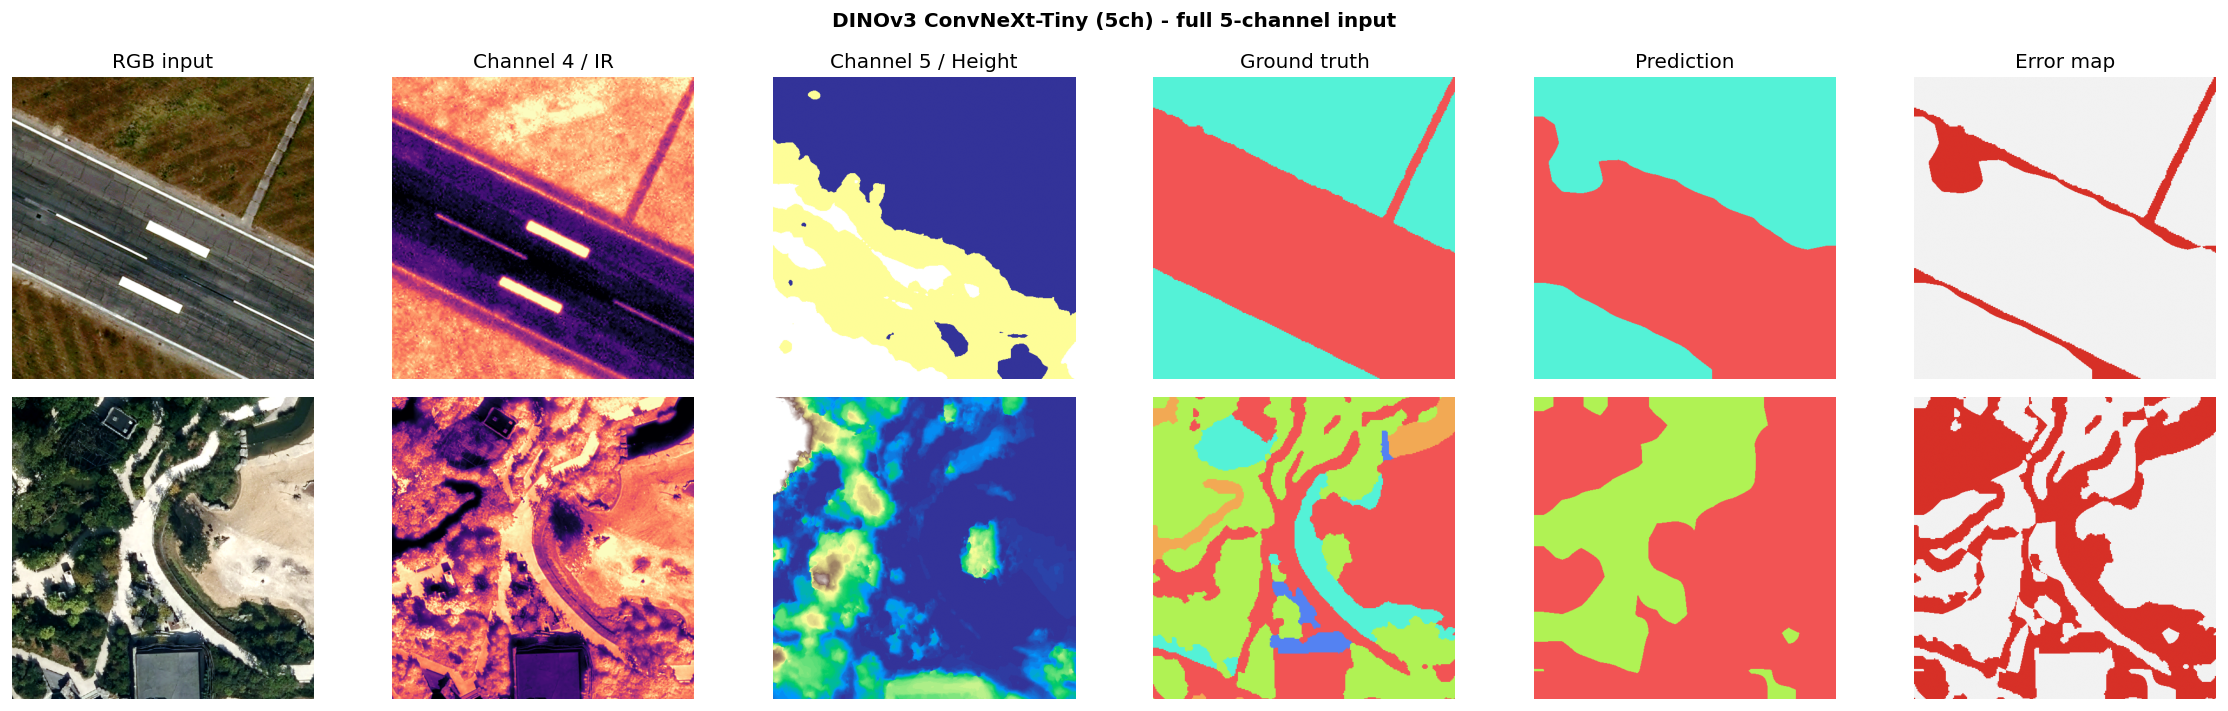

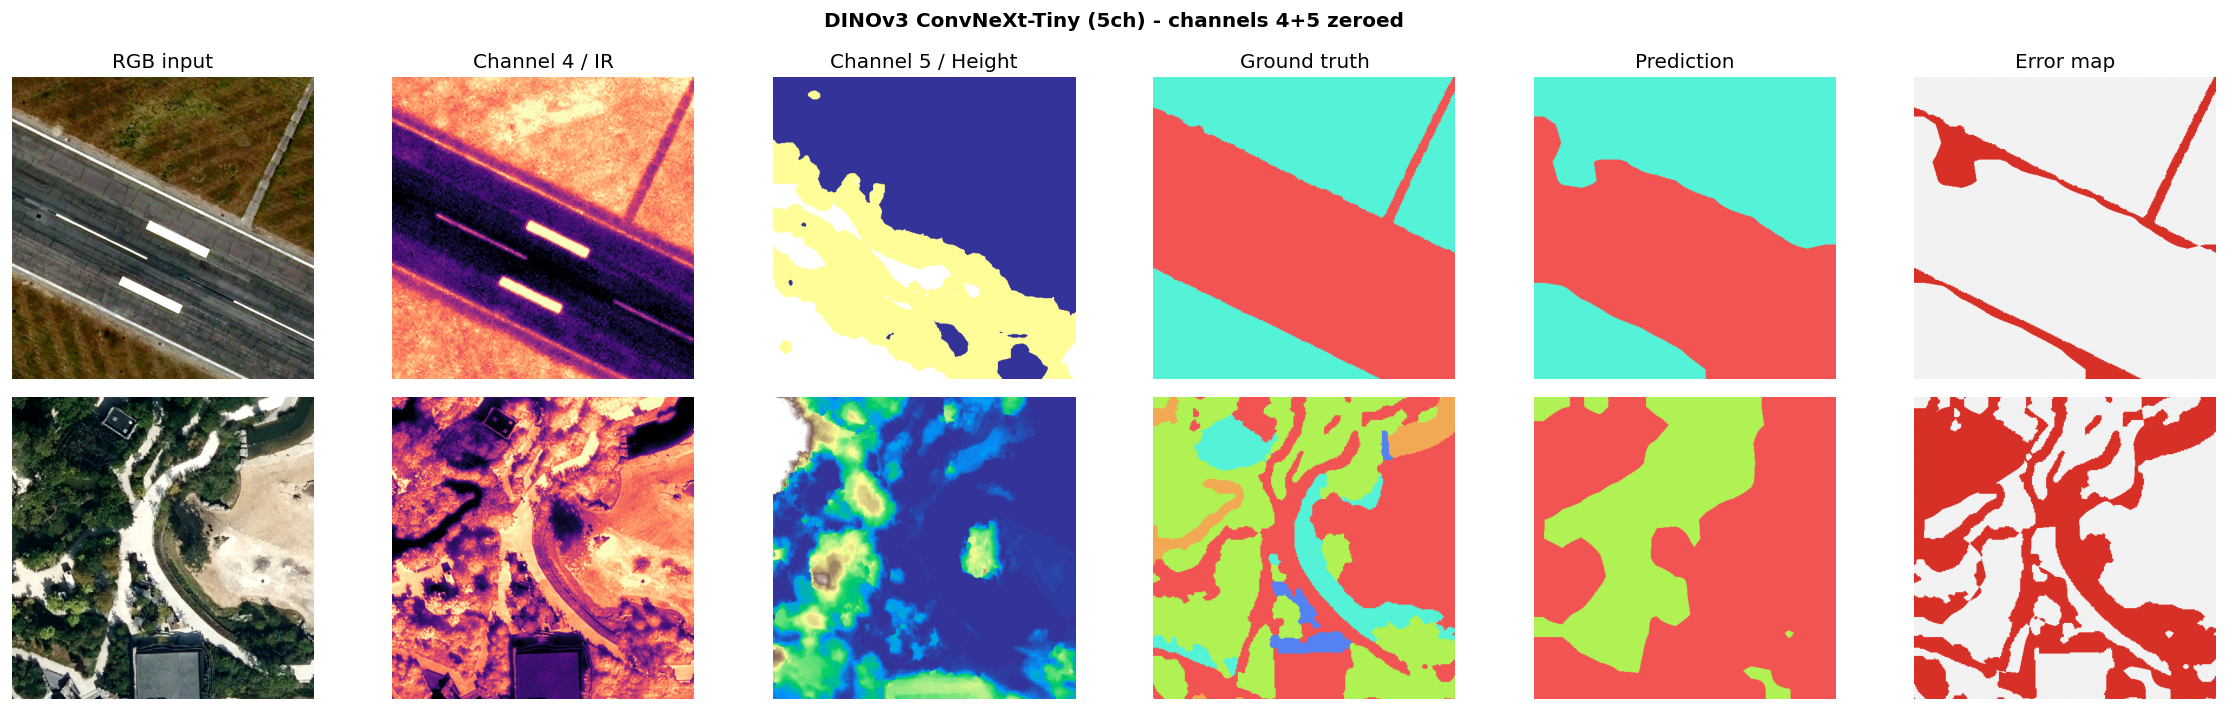

selected 5ch sample indices: [1, 12]
saved: /home/henry/Documents/Coursework/DLE_24788/final_project/DLE-Flair-Segmentation/notebooks/outputs/reproduce_results/tables/5ch_channel_ablation_metrics.csv
saved: /home/henry/Documents/Coursework/DLE_24788/final_project/DLE-Flair-Segmentation/notebooks/outputs/reproduce_results/figures/5ch_channel_ablation_full_grid.png
saved: /home/henry/Documents/Coursework/DLE_24788/final_project/DLE-Flair-Segmentation/notebooks/outputs/reproduce_results/figures/5ch_channel_ablation_rgb_only_grid.png


In [10]:
from src.utils import zero_channel_transform
from src.visualize import plot_extra_channel_context_grid

CHANNEL_ABLATIONS = [
    {"key": "full_5ch", "label": "Full 5ch", "zero_channels": []},
    {"key": "rgb_only", "label": "Channels 4+5 zeroed", "zero_channels": [3, 4]},
]

for run_key, run in RUNS_5CH.items():
    run["checkpoint_path"] = resolve_checkpoint(run["checkpoints"])
    run["config_obj"] = load_run_config(run["config"])
    config = run["config_obj"]
    assert config["checkpoint"]["monitor"] == "val_IoU"
    assert config["checkpoint"]["mode"] == "max"
    assert config["model"]["in_channels"] == 5
    assert config["data"]["channels"] == [1, 2, 3, 4, 5]
    print(f"{run_key}: {run['checkpoint_path'].relative_to(REPO_ROOT)}")

loaded_5ch = {}
ablation_rows = []

for run_key, run in RUNS_5CH.items():
    print(f"\nLoading {run['label']}")
    config = run["config_obj"]
    model, checkpoint = load_checkpoint_model(run["checkpoint_path"], DEVICE, model_config=config["model"])
    _, _, test_loader = build_dataloaders(config["data"])

    for ablation in CHANNEL_ABLATIONS:
        metrics = evaluate_test_metrics(
            model=model,
            dataloader=test_loader,
            num_classes=NUM_CLASSES,
            device=DEVICE,
            ignore_index=IGNORE_INDEX,
            class_names=CLASS_NAMES,
            input_transform=zero_channel_transform(ablation["zero_channels"]),
            desc=f"{run['label']} test - {ablation['label']}",
        )
        ablation_rows.append({
            "run_key": run_key,
            "model": run["label"],
            "condition_key": ablation["key"],
            "condition": ablation["label"],
            "zero_channels": ",".join(str(channel + 1) for channel in ablation["zero_channels"]) or "none",
            "checkpoint_epoch": checkpoint.get("epoch"),
            "checkpoint_best_metric": checkpoint.get("best_metric"),
            "pixel_accuracy": metrics["pixel_accuracy"],
            "mIoU": metrics["mIoU"],
            "mean_dice": metrics["mean_dice"],
            "latency_ms_per_patch": metrics["latency_ms_per_patch"],
            "num_pixels": metrics["num_pixels"],
        })

    loaded_5ch[run_key] = {
        "model": model,
        "checkpoint": checkpoint,
        "config": config,
        "test_loader": test_loader,
    }

ablation_df = pd.DataFrame(ablation_rows)
full_metrics = ablation_df[ablation_df["condition_key"] == "full_5ch"].set_index("run_key")
for metric in ["mIoU", "mean_dice", "pixel_accuracy"]:
    ablation_df[f"delta_{metric}"] = ablation_df.apply(
        lambda row: row[metric] - full_metrics.loc[row["run_key"], metric],
        axis=1,
    )

ablation_df = ablation_df.sort_values(["model", "condition_key"]).reset_index(drop=True)
ablation_df.to_csv(TABLE_DIR / "5ch_channel_ablation_metrics.csv", index=False)

display_columns = [
    "model",
    "condition",
    "pixel_accuracy",
    "mIoU",
    "mean_dice",
    "delta_pixel_accuracy",
    "delta_mIoU",
    "delta_mean_dice",
]
display(ablation_df[display_columns])

best_5ch_run_key = (
    ablation_df[ablation_df["condition_key"] == "full_5ch"]
    .sort_values("mIoU", ascending=False)
    .iloc[0]["run_key"]
)
best_5ch_item = loaded_5ch[best_5ch_run_key]
best_5ch_label = RUNS_5CH[best_5ch_run_key]["label"]
channel_sample_indices = (selected_indices if "selected_indices" in globals() else MANUAL_SAMPLE_INDICES)[:2]
channel_images, channel_masks = collect_samples_by_index(best_5ch_item["test_loader"], channel_sample_indices)


@torch.no_grad()
def predict_with_optional_zeroing(model, images: torch.Tensor, zero_channels: list[int] | None = None) -> torch.Tensor:
    transform = zero_channel_transform(zero_channels or [])
    model_images = transform(images) if transform is not None else images
    logits = model(model_images.to(DEVICE))
    return logits.argmax(dim=1).detach().cpu()


full_5ch_predictions = predict_with_optional_zeroing(best_5ch_item["model"], channel_images)
rgb_only_predictions = predict_with_optional_zeroing(best_5ch_item["model"], channel_images, zero_channels=[3, 4])
extra_channels = [
    {"index": 3, "label": "Channel 4 / IR", "cmap": "magma"},
    {"index": 4, "label": "Channel 5 / Height", "cmap": "terrain"},
]

full_grid = plot_extra_channel_context_grid(
    images=channel_images,
    masks=channel_masks,
    predictions=full_5ch_predictions,
    extra_channels=extra_channels,
    max_items=len(channel_sample_indices),
    rgb_channels=(0, 1, 2),
    class_names=CLASS_NAMES,
    ignore_index=IGNORE_INDEX,
    title=f"{best_5ch_label} - full 5-channel input",
)
full_grid.savefig(FIG_DIR / "5ch_channel_ablation_full_grid.png", bbox_inches="tight")
plt.show()

rgb_only_grid = plot_extra_channel_context_grid(
    images=channel_images,
    masks=channel_masks,
    predictions=rgb_only_predictions,
    extra_channels=extra_channels,
    max_items=len(channel_sample_indices),
    rgb_channels=(0, 1, 2),
    class_names=CLASS_NAMES,
    ignore_index=IGNORE_INDEX,
    title=f"{best_5ch_label} - channels 4+5 zeroed",
)
rgb_only_grid.savefig(FIG_DIR / "5ch_channel_ablation_rgb_only_grid.png", bbox_inches="tight")
plt.show()

print("selected 5ch sample indices:", channel_sample_indices)
print("saved:", TABLE_DIR / "5ch_channel_ablation_metrics.csv")
print("saved:", FIG_DIR / "5ch_channel_ablation_full_grid.png")
print("saved:", FIG_DIR / "5ch_channel_ablation_rgb_only_grid.png")


## Conformal Prediction Results

/content/drive/MyDrive/Deep Learning Project/DLE-Flair-Segmentation/notebooks
Repo root: /content/drive/MyDrive/Deep Learning Project/DLE-Flair-Segmentation
Using device: cpu
Alpha: 0.1
Target coverage: 90%
Classes (6): ['Background', 'Building', 'Pervious surface', 'Impervious surface', 'Bare soil', 'Water']
Model : ResNet34-UNet (3ch)
Checkpoint: outputs/resnet34_unet_3ch_val_IoU/best.pt
Loaders: train=25 val=4 test=4 batches
images torch.Size([8, 3, 512, 512])  masks torch.Size([8, 512, 512])  classes [0, 2, 3, 4, 5]


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Model loaded


...

Calibrating: 100%|██████████| 4/4 [00:35<00:00,  8.97s/it]



Calibration pixels: 6,553,600
Score distribution: min=0.0074  mean=0.3799  max=0.9998
α = 0.1: target coverage = 90%
q̂ = 0.7836: inclusion threshold p_c must be greater than equal to 0.2164

Interpretation:
  A class is included in the prediction set when its softmax score is greater than equal to 0.2164.


Evaluating: 100%|██████████| 4/4 [00:38<00:00,  9.73s/it]


Coverage: 84.99%
Avg set size: 1.52
Per-class coverage: [0.97514951 0.34449021 0.88354545 0.82333453 0.82724653 0.51000905]
  Model       : ConvNext-Tiny (5ch)
  α           : 0.1
  q̂           : 0.7836
  Threshold   : 0.2164
++++++++++++++++++++++++++++++++++++++++++++++++++++
  Target  coverage : 90.00%
  Empirical coverage: 84.99%  Below Target
  Avg set size : 1.523 / 6 classes
++++++++++++++++++++++++++++++++++++++++++++++++++++
  Per-class coverage:
    Satisfied     -  Background                 97.51%  |███████████████████
    Not Satisfied -  Building                   34.45%  |██████
    Not Satisfied -  Pervious surface           88.35%  |█████████████████
    Not Satisfied -  Impervious surface         82.33%  |████████████████
    Not Satisfied -  Bare soil                  82.72%  |████████████████
    Not Satisfied -  Water                      51.00%  |██████████
Model : DINOv3-ConvNext-Tiny (3ch)
Checkpoint: outputs/dinov3_convnext_tiny_3ch_val_IoU/best.pt
Loaders: tr

OSError: You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/facebook/dinov3-convnext-tiny-pretrain-lvd1689m.
401 Client Error. (Request ID: Root=1-69f39b9f-4bd0c2421dfb8daa0f2d7402;4712383e-5510-4c63-bc61-d4f67a8c5098)

Cannot access gated repo for url https://huggingface.co/facebook/dinov3-convnext-tiny-pretrain-lvd1689m/resolve/main/config.json.
Access to model facebook/dinov3-convnext-tiny-pretrain-lvd1689m is restricted. You must have access to it and be authenticated to access it. Please log in.

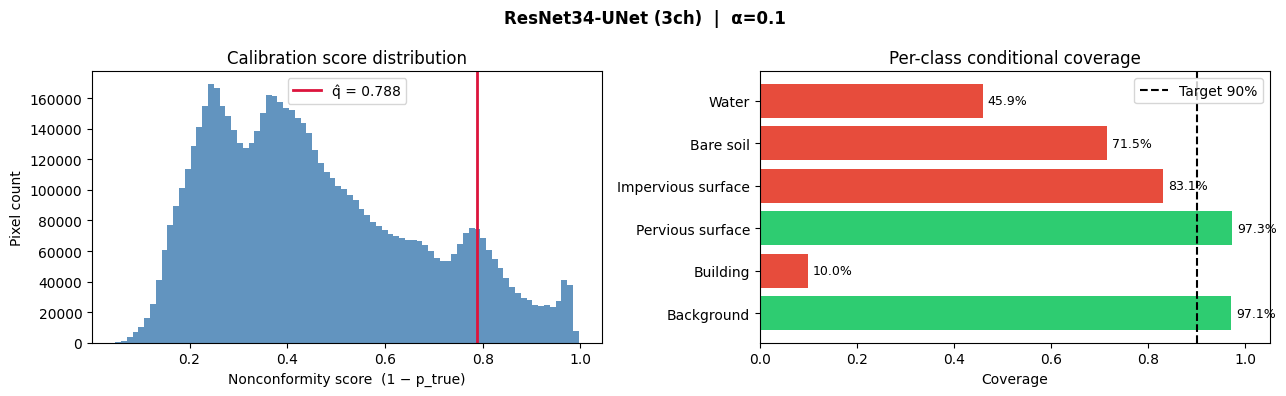

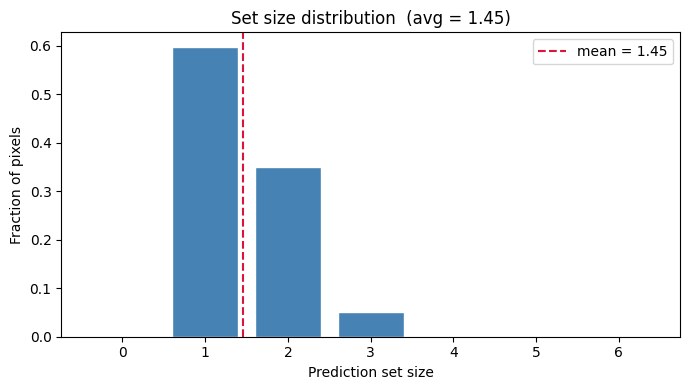

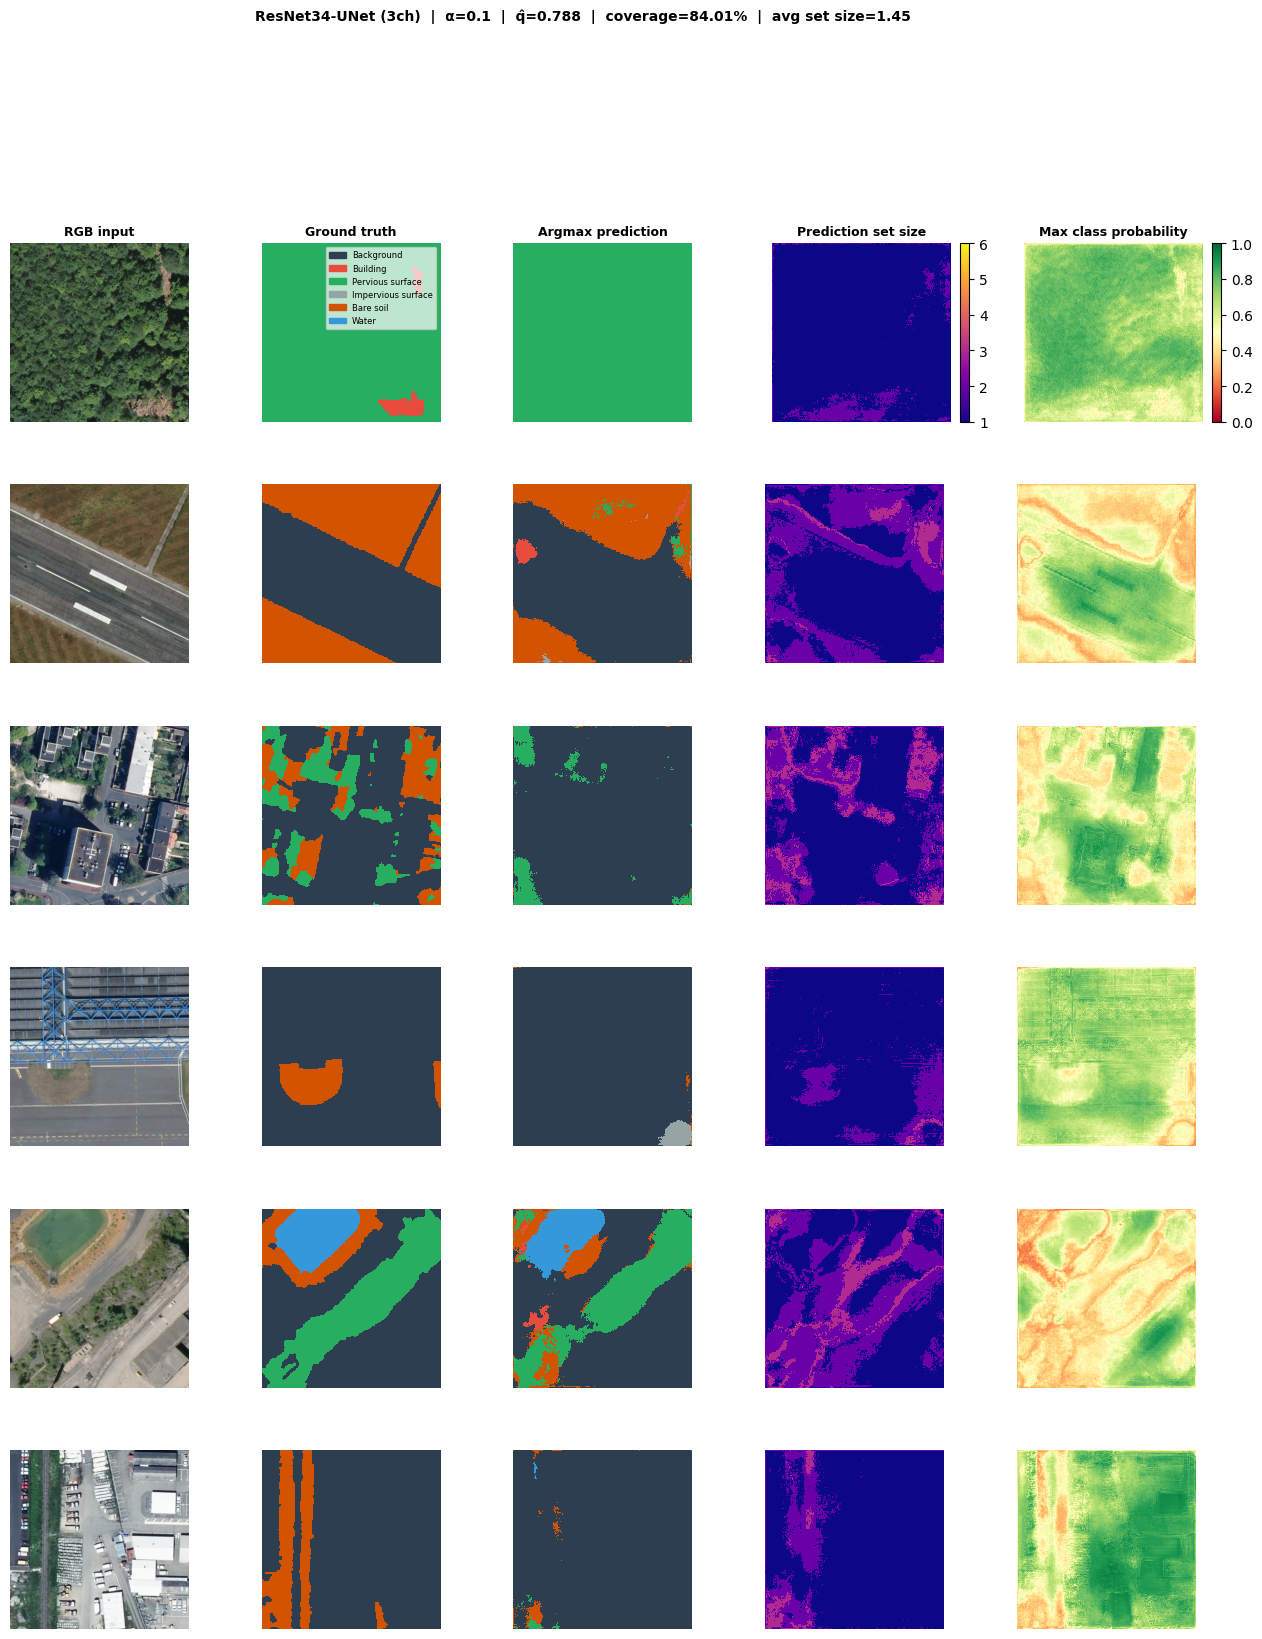

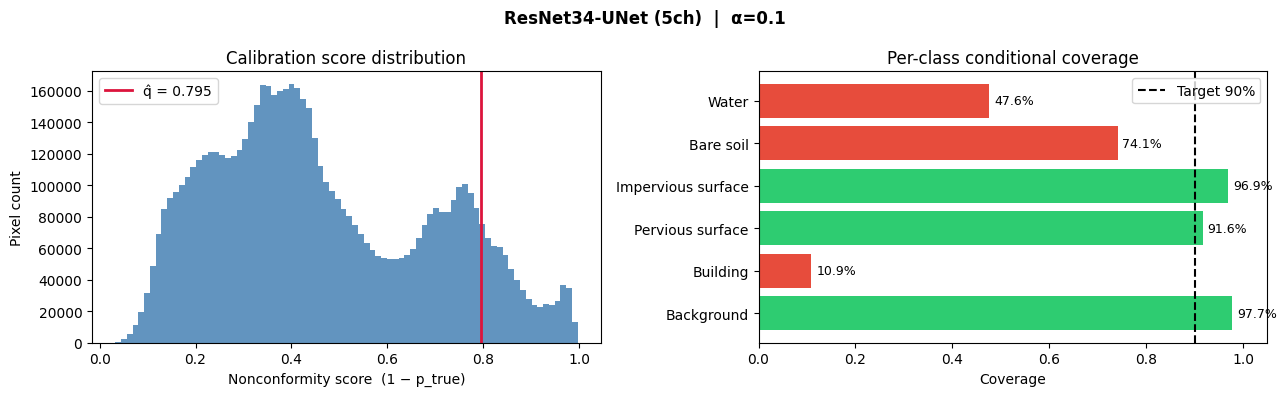

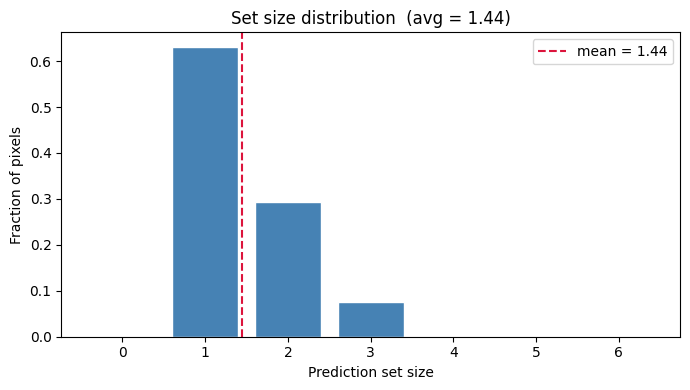

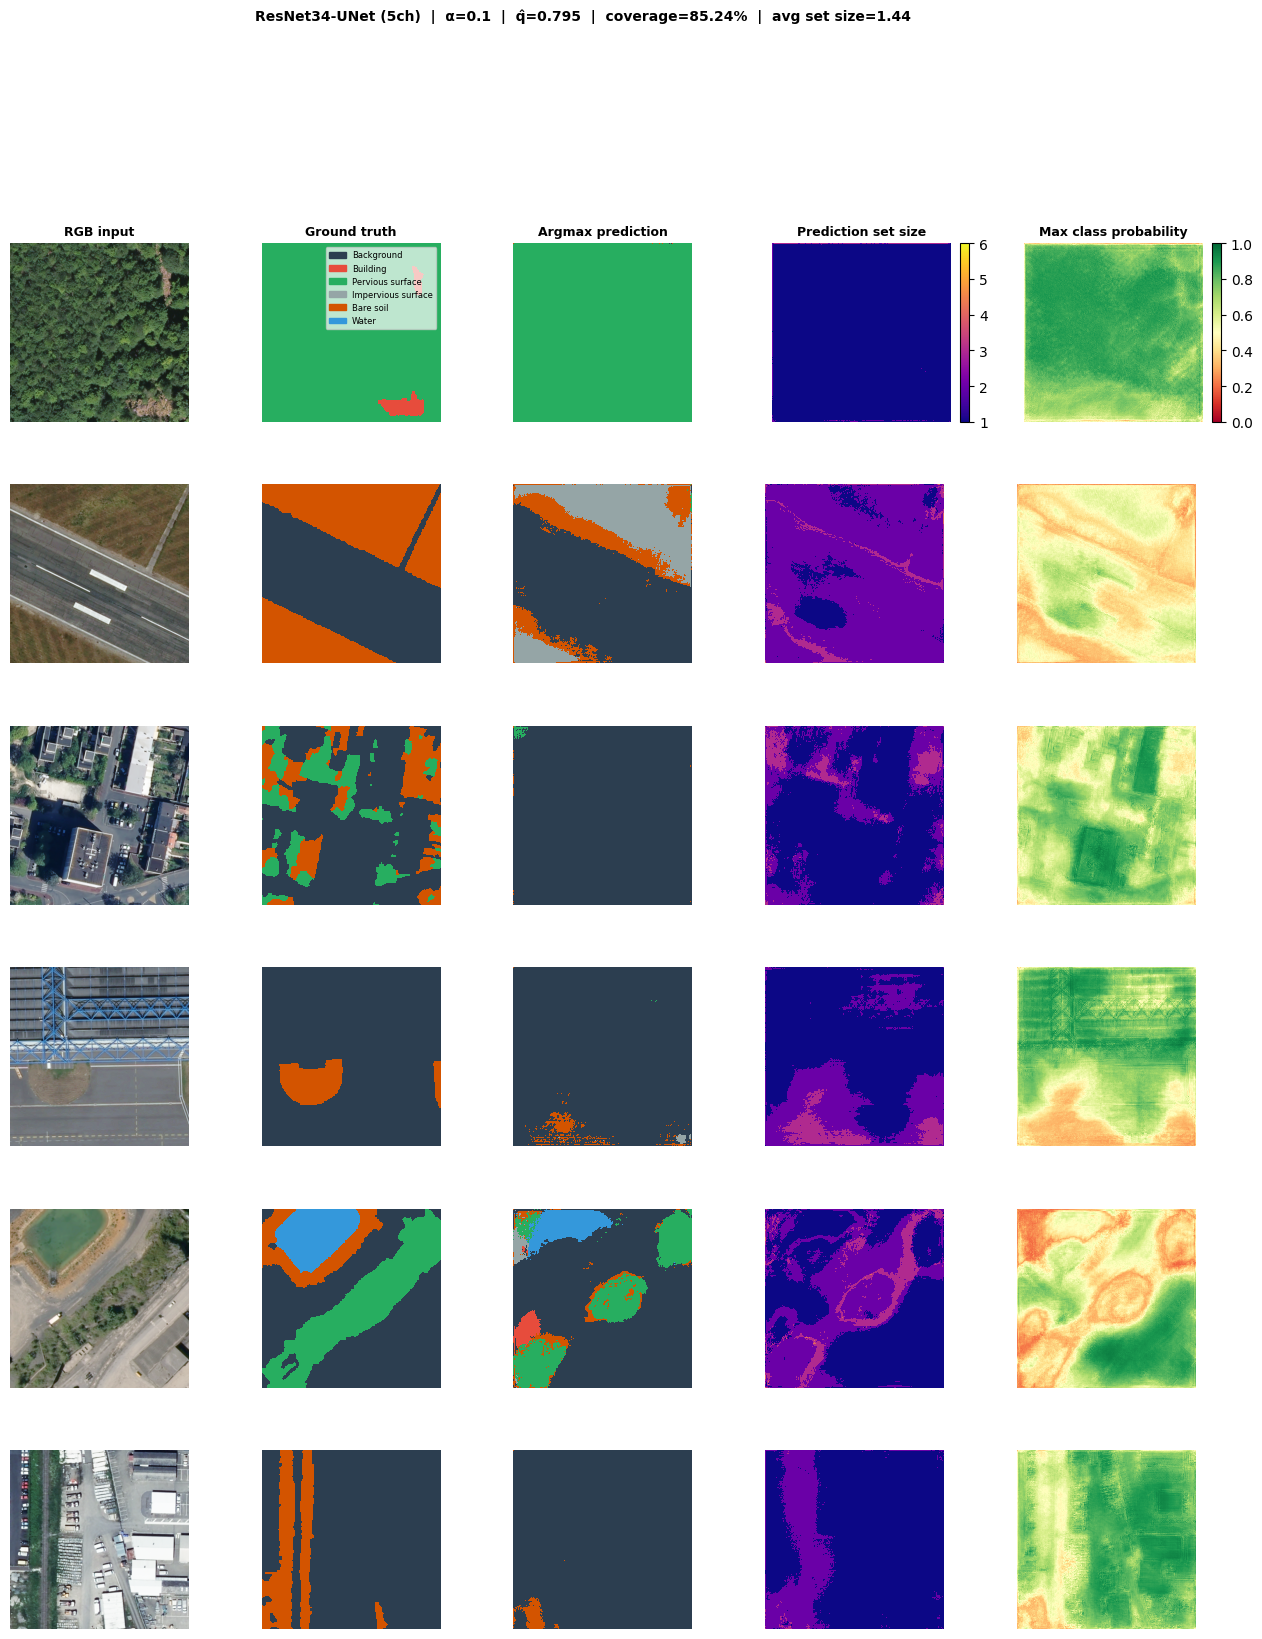

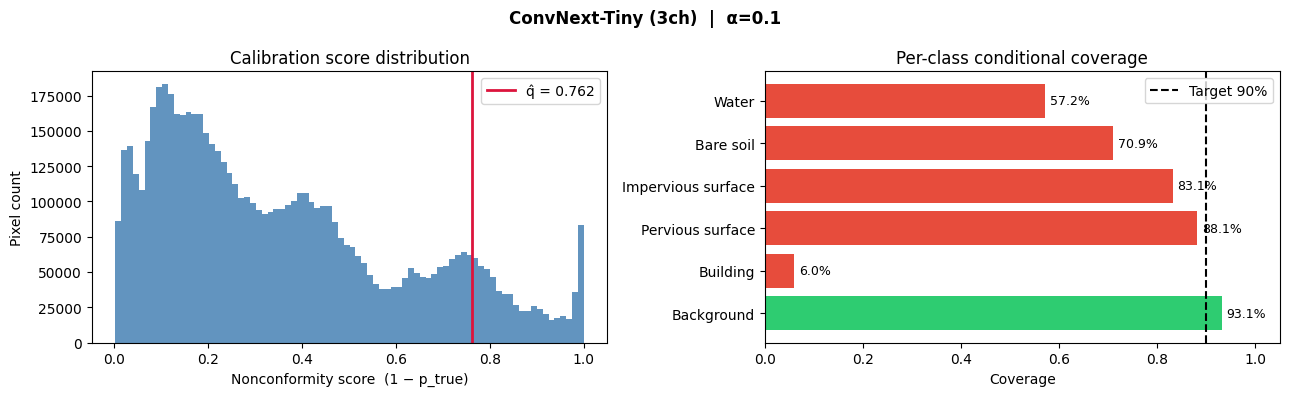

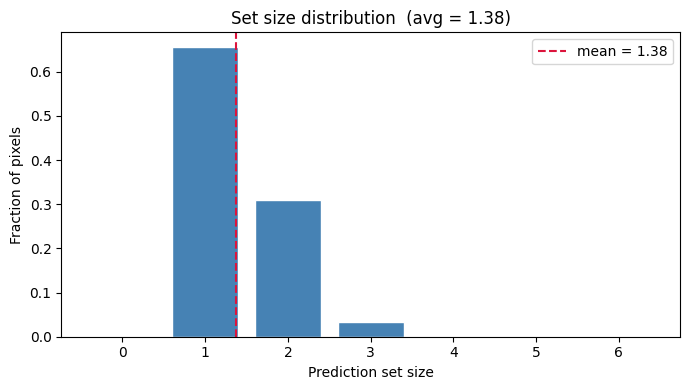

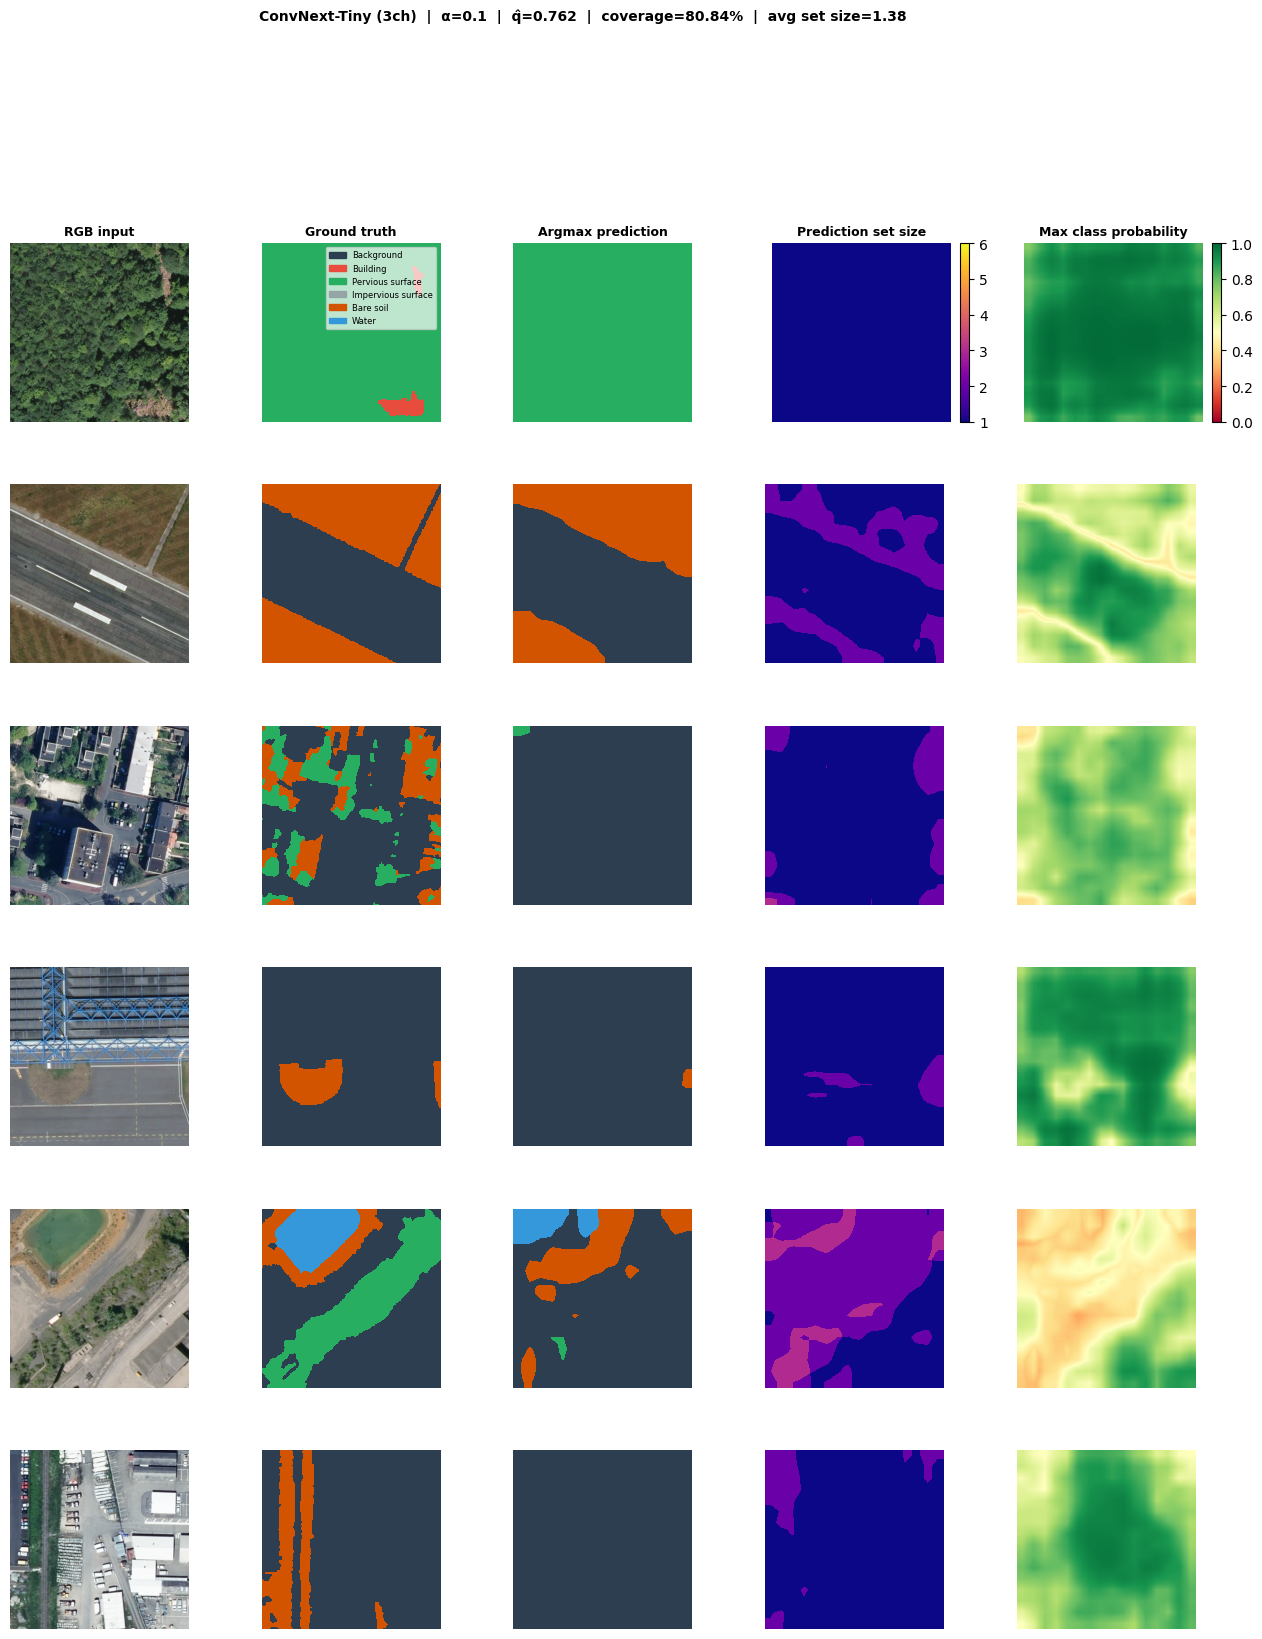

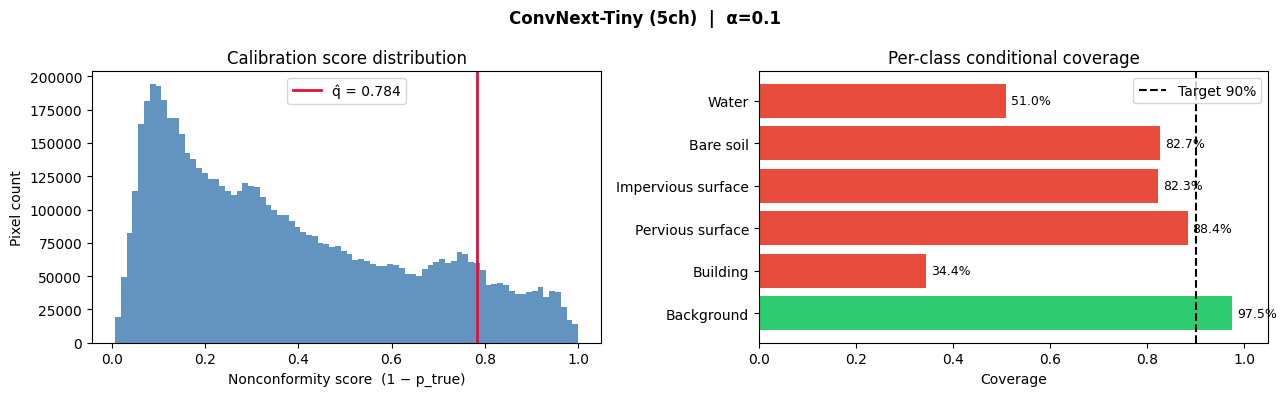

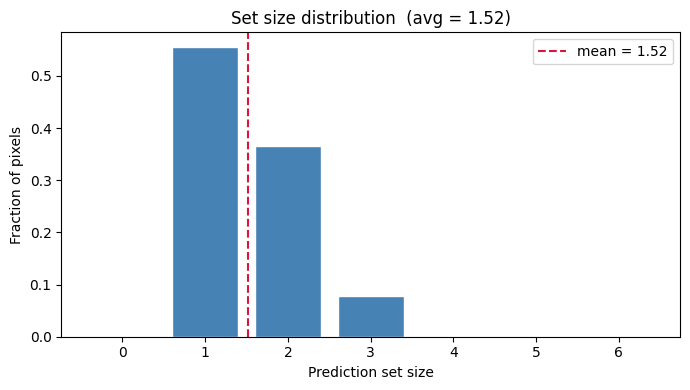

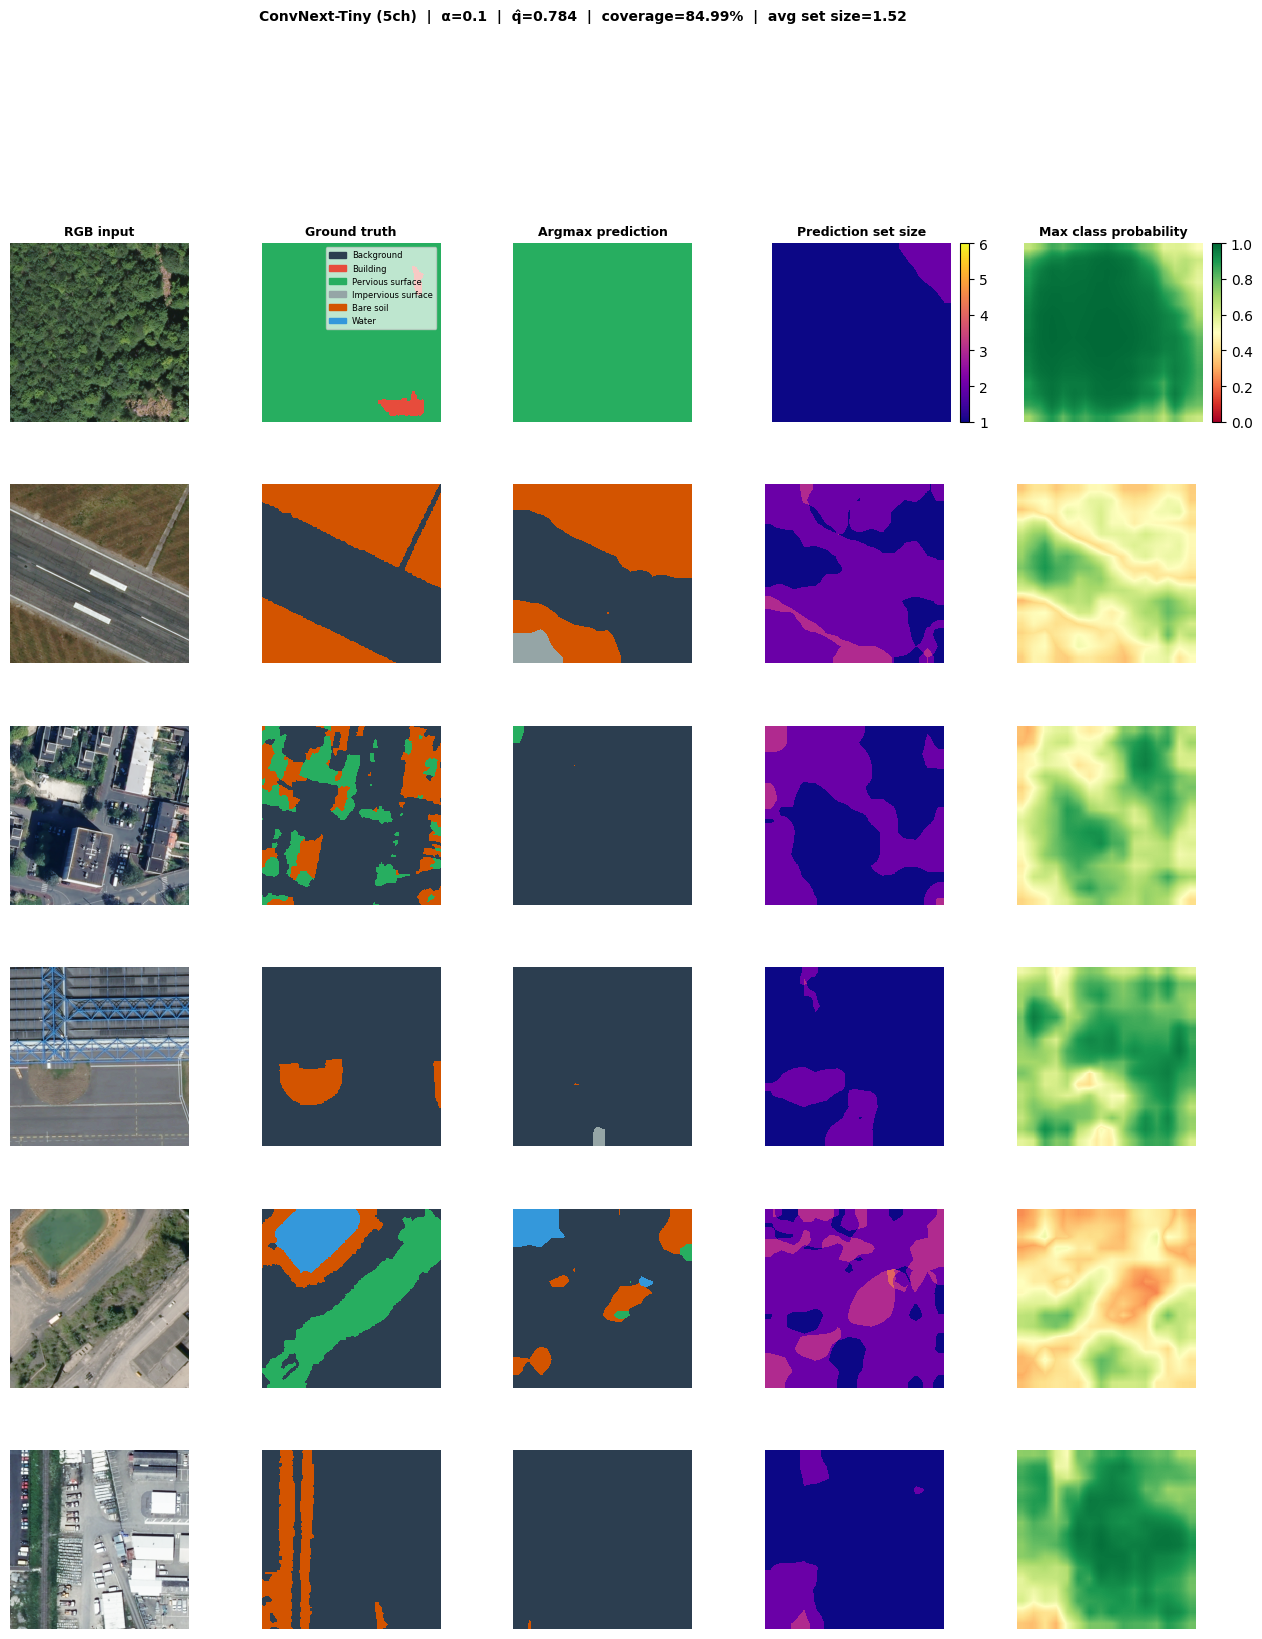

In [8]:
#!pip install import_ipynb
%cd /content/drive/MyDrive/Deep Learning Project/DLE-Flair-Segmentation/notebooks
import import_ipynb
import conformal_prediction